# Solution 5B: Smooth Weight Functions
**BUSI 722: Data-Driven Finance II**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

preds = pd.read_parquet("expanding_predictions.parquet")
print(f"Predictions: {len(preds):,} stock-months, {preds['month'].min()} to {preds['month'].max()}")

preds["u"] = preds.groupby("month")["pred"].transform(lambda x: x.rank(pct=True))

Predictions: 66,121 stock-months, 2024-01 to 2025-11


## 1-4. Compute portfolio returns for each weight function

In [2]:
results = {}
for m, grp in preds.groupby("month"):
    u = grp["u"].values
    ret = grp["return"].values

    # Linear
    w = u - 0.5
    w = w / np.abs(w).sum()
    r_lin = np.sum(w * ret)

    # Power
    w = u ** 3
    w = w - w.mean()
    w = w / np.abs(w).sum()
    r_pow = np.sum(w * ret)

    # Exponential
    w = np.exp(2 * u)
    w = w - w.mean()
    w = w / np.abs(w).sum()
    r_exp = np.sum(w * ret)

    # Softmax
    w = np.exp(u / 0.5)
    w = w / w.sum()
    r_soft = np.sum(w * ret)

    results[m] = {"Linear": r_lin, "Power (p=3)": r_pow,
                  "Exponential": r_exp, "Softmax (T=0.5)": r_soft}

smooth_df = pd.DataFrame(results).T.sort_index()

print(f"{'Weight Function':20s} {'Mean Mo':>10s} {'Ann Vol':>10s} {'Sharpe':>10s}")
print("-" * 52)
for col in smooth_df.columns:
    s = smooth_df[col]
    sr = s.mean() / s.std() * np.sqrt(12) if s.std() > 0 else 0
    print(f"{col:20s} {s.mean():10.4f} {s.std()*np.sqrt(12):10.4f} {sr:10.3f}")

Weight Function         Mean Mo    Ann Vol     Sharpe
----------------------------------------------------
Linear                   0.0105     0.0531      2.381
Power (p=3)              0.0073     0.0457      1.915
Exponential              0.0087     0.0492      2.127
Softmax (T=0.5)          0.0084     0.1524      0.664


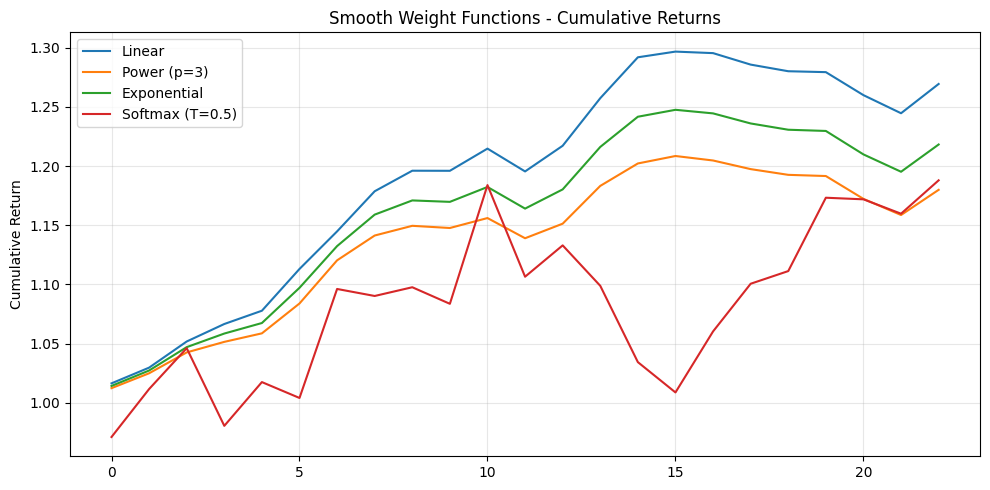

Saved: smooth_portfolio_returns.parquet


In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
for col in smooth_df.columns:
    ax.plot(range(len(smooth_df)), (1 + smooth_df[col]).cumprod().values, label=col)
ax.set_title("Smooth Weight Functions - Cumulative Returns")
ax.set_ylabel("Cumulative Return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

smooth_df.to_parquet("smooth_portfolio_returns.parquet")
print("Saved: smooth_portfolio_returns.parquet")